# Chapter 11 — Advanced Sensor Technologies
## Hands-On Python Practice: Optical, Chemical, Biometric, and Multi-Sensor Environmental Systems

**Fundamentals of the Internet of Things** (Elsevier / Morgan Kaufmann)
Oleksandr Kuznetsov · eCampus University

---

This notebook contains the four hands-on exercises referenced in Section 11.3 of the textbook. Each exercise is self-contained and can be run independently, but Exercise 11.4 reuses the MOS gas-sensor model introduced in Exercise 11.2, so it is best run after it.

| Exercise | Topic | Key technique | Sensor family |
|---|---|---|---|
| 11.1 | Optical spectroscopic sensing | One-to-one peak matching, precision/recall/F1, mixture-robustness check | Optical |
| 11.2 | Chemical gas sensing | Power-law calibration, band-wise relative error, local cross-sensitivity | Chemical (MOS) |
| 11.3 | Multimodal biometrics | Cluster (identity-level) bootstrap ROC/EER, score-level fusion | Biometric |
| 11.4 | Environmental monitoring | Empirically-calibrated fusion threshold, multi-day Monte Carlo | Optical + chemical |

**Reproducibility.** Every exercise uses NumPy's `Generator` API (`np.random.default_rng(seed)`) with fixed seeds, stated explicitly at the start of each exercise, so every reader obtains the same results shown in the book.

**A note on evaluation methodology.** Every exercise below pairs its signal-processing technique with an equally deliberate evaluation methodology, because a sensor system's apparent performance depends as much on how it is measured as on the underlying processing itself. This means: matching detected features to ground truth one-to-one rather than allowing a lenient many-to-one shortcut to hide errors (Exercise 11.1); reporting calibration error in relative, band-wise terms rather than one absolute number dominated by the top of a wide range (Exercise 11.2); using a sample size, and a bootstrap resampling unit, that actually match the statistical claim being made (Exercise 11.3); and calibrating a detection threshold on data held strictly separate from the data it is then evaluated against (Exercise 11.4). These choices are discussed explicitly at the point where each matters, because recognising this class of evaluation pitfall is as much a transferable skill as any individual signal-processing technique.

**How to work through this notebook.** Read the *Background* markdown cell for an exercise, run its code cells in order, study the printed metrics and figures, and only then attempt the *Challenge Tasks* at the end of the exercise.


In [1]:
# ── Global setup ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import warnings

warnings.filterwarnings("ignore", message=".*not compatible with tight_layout.*")

ELS_BLUE = "#005A9C"
RED      = "#D9534F"
GREEN    = "#2E8B57"
ORANGE   = "#E8A33D"
PALETTE  = [ELS_BLUE, RED, GREEN, ORANGE, "#7A5FA0"]

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("Setup complete.")

Setup complete.


---
## Exercise 11.1 — Optical Spectroscopic Sensor: Substance Identification

### Background

Optical sensors identify a substance from the way it absorbs or emits light at specific wavelengths (Section 11.2.1). This exercise builds a small reference library of four synthetic substances, simulates a noisy spectrometer, and evaluates peak detection *honestly* — with one-to-one matching and separate precision/recall/F1 — rather than trusting a single accuracy number that can hide a poorly calibrated detector. The noise-only sweep below has a specific limitation worth naming up front: it tests every "unknown" spectrum as an exact, pure draw from the reference library, which is a closed-world assumption that can flatter any classifier. A supplementary test at the end injects **partial spectral mixtures** (an "unknown" that is really a blend of two substances, mimicking an impure field sample) to check whether that assumption was doing more work than genuine noise robustness.

### Learning objectives
- Simulate multi-peak optical spectra and additive detector/readout noise.
- Evaluate peak detection with one-to-one matching and precision/recall/F1, not a lenient many-to-one shortcut.
- Compare a peak-based classifier against a full-spectrum correlation baseline, including under a mixture nuisance factor absent from the main noise sweep.


In [2]:
# ── Reference spectral library ──────────────────────────────────────
WAVELENGTHS = np.arange(400, 900, 1.0)

REFERENCE_LIBRARY = {
    "Substance A": [(450, 0.90, 12), (680, 1.00, 10)],
    "Substance B": [(500, 0.85, 15), (750, 0.60, 20)],
    "Substance C": [(420, 0.70, 10), (600, 0.95, 12), (850, 0.50, 25)],
    "Substance D": [(480, 1.00, 8),  (630, 0.40, 15)],
}
SUBSTANCE_NAMES = list(REFERENCE_LIBRARY.keys())


def generate_spectrum(peaks, wavelengths=WAVELENGTHS):
    spectrum = np.zeros_like(wavelengths, dtype=float)
    for wl, intensity, width in peaks:
        spectrum += intensity * np.exp(-(wavelengths - wl) ** 2 / (2 * width ** 2))
    return spectrum


def add_noise(spectrum, noise_level, rng):
    return spectrum + rng.normal(0, noise_level, spectrum.shape)


def detect_peaks(spectrum, wavelengths=WAVELENGTHS, prominence=0.15, height=0.15):
    idx, _ = find_peaks(spectrum, height=height, prominence=prominence, distance=5)
    return wavelengths[idx], spectrum[idx]


print("Reference library ready:", SUBSTANCE_NAMES)

Reference library ready: ['Substance A', 'Substance B', 'Substance C', 'Substance D']


In [3]:
# ── One-to-one peak matching and detection-quality metrics ─────────
def match_peaks_greedy(detected_wl, true_peaks, tolerance=8.0):
    true_wl = np.array([p[0] for p in true_peaks])
    candidates = [(abs(dwl - twl), di, ti)
                  for di, dwl in enumerate(detected_wl)
                  for ti, twl in enumerate(true_wl)
                  if abs(dwl - twl) <= tolerance]
    candidates.sort(key=lambda c: c[0])
    matched_d, matched_t, matches = set(), set(), []
    for d, di, ti in candidates:
        if di not in matched_d and ti not in matched_t:
            matches.append((di, ti, d))
            matched_d.add(di); matched_t.add(ti)
    unmatched_detected = [i for i in range(len(detected_wl)) if i not in matched_d]
    unmatched_true = [i for i in range(len(true_wl)) if i not in matched_t]
    return matches, unmatched_detected, unmatched_true


def peak_detection_metrics(detected_wl, true_peaks, tolerance=8.0):
    matches, unmatched_d, unmatched_t = match_peaks_greedy(detected_wl, true_peaks, tolerance)
    tp, fp, fn = len(matches), len(unmatched_d), len(unmatched_t)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (tp > 0) else 0.0
    errors = [d for _, _, d in matches]
    return precision, recall, f1, errors

In [4]:
# ── Two classifiers: peak-based (penalising false peaks) and a ─────
# ── full-spectrum correlation baseline ──────────────────────────────
def match_score(detected_wl, reference_peaks, tolerance=8.0,
                 miss_penalty=0.3, false_peak_penalty=0.15):
    matches, unmatched_d, unmatched_t = match_peaks_greedy(detected_wl, reference_peaks, tolerance)
    ref_amp = np.array([p[1] for p in reference_peaks])
    score = sum(ref_amp[ti] for _, ti, _ in matches)
    score -= miss_penalty * sum(ref_amp[ti] for ti in unmatched_t)
    score -= false_peak_penalty * len(unmatched_d) * ref_amp.mean()
    return score / ref_amp.sum()


def classify_peak_based(detected_wl, library=REFERENCE_LIBRARY, tolerance=8.0):
    scores = {name: match_score(detected_wl, peaks, tolerance) for name, peaks in library.items()}
    return max(scores, key=scores.get)


def classify_correlation(noisy_spectrum, library=REFERENCE_LIBRARY, wavelengths=WAVELENGTHS):
    scores = {name: np.corrcoef(noisy_spectrum, generate_spectrum(peaks, wavelengths))[0, 1]
              for name, peaks in library.items()}
    return max(scores, key=scores.get)

In [5]:
# ── Monte Carlo experiment: detection quality AND both classifiers ─
NOISE_LEVELS = [0.02, 0.04, 0.06, 0.08, 0.10, 0.14]
N_TRIALS = 300
rng = np.random.default_rng(42)

precision_vs_noise, recall_vs_noise, f1_vs_noise = [], [], []
cond_rmse_vs_noise, mean_fp_vs_noise = [], []
peak_acc_vs_noise, corr_acc_vs_noise = [], []

for noise_level in NOISE_LEVELS:
    precs, recs, f1s, all_err, fp_counts = [], [], [], [], []
    correct_peak, correct_corr = 0, 0
    for _ in range(N_TRIALS):
        true_name = SUBSTANCE_NAMES[rng.integers(0, len(SUBSTANCE_NAMES))]
        true_peaks = REFERENCE_LIBRARY[true_name]
        noisy = add_noise(generate_spectrum(true_peaks), noise_level, rng)
        det_wl, det_amp = detect_peaks(noisy)

        p, r, f1, errs = peak_detection_metrics(det_wl, true_peaks)
        precs.append(p); recs.append(r); f1s.append(f1); all_err.extend(errs)
        matches, unmatched_d, unmatched_t = match_peaks_greedy(det_wl, true_peaks)
        fp_counts.append(len(unmatched_d))

        correct_peak += (classify_peak_based(det_wl) == true_name)
        correct_corr += (classify_correlation(noisy) == true_name)

    precision_vs_noise.append(np.nanmean(precs))
    recall_vs_noise.append(np.nanmean(recs))
    f1_vs_noise.append(np.nanmean(f1s))
    cond_rmse_vs_noise.append(np.sqrt(np.mean(np.square(all_err))) if all_err else np.nan)
    mean_fp_vs_noise.append(np.mean(fp_counts))
    peak_acc_vs_noise.append(correct_peak / N_TRIALS)
    corr_acc_vs_noise.append(correct_corr / N_TRIALS)

print(f"{'noise':>6} {'precision':>10} {'recall':>8} {'F1':>6} {'cond.RMSE':>10} {'mean FP':>8} "
      f"{'peak acc':>9} {'corr acc':>9}")
for i, nl in enumerate(NOISE_LEVELS):
    print(f"{nl:6.2f} {precision_vs_noise[i]:10.3f} {recall_vs_noise[i]:8.3f} {f1_vs_noise[i]:6.3f} "
          f"{cond_rmse_vs_noise[i]:10.2f} {mean_fp_vs_noise[i]:8.2f} "
          f"{peak_acc_vs_noise[i]*100:8.1f}% {corr_acc_vs_noise[i]*100:8.1f}%")

 noise  precision   recall     F1  cond.RMSE  mean FP  peak acc  corr acc
  0.02      1.000    1.000  1.000       1.93     0.00    100.0%    100.0%
  0.04      0.908    0.991  0.940       2.51     0.33    100.0%    100.0%
  0.06      0.314    0.994  0.470       2.52     5.57     98.0%    100.0%
  0.08      0.117    0.999  0.208       2.38    17.69     70.7%    100.0%
  0.10      0.070    0.999  0.131       2.48    29.56     31.3%    100.0%
  0.14      0.048    1.000  0.092       2.36    45.28     28.7%    100.0%


In [6]:
# ── Confusion matrix (peak-based classifier) at the operating noise level
OPERATING_NOISE = 0.06
N_CONF_TRIALS = 200
n_classes = len(SUBSTANCE_NAMES)
confusion = np.zeros((n_classes, n_classes), dtype=int)

for _ in range(N_CONF_TRIALS):
    true_idx = rng.integers(0, n_classes)
    true_name = SUBSTANCE_NAMES[true_idx]
    noisy = add_noise(generate_spectrum(REFERENCE_LIBRARY[true_name]), OPERATING_NOISE, rng)
    det_wl, _ = detect_peaks(noisy)
    pred_name = classify_peak_based(det_wl)
    confusion[true_idx, SUBSTANCE_NAMES.index(pred_name)] += 1

overall_acc = np.trace(confusion) / confusion.sum()
print(f"Confusion matrix (peak-based classifier) at noise = {OPERATING_NOISE} "
      f"(overall accuracy = {overall_acc*100:.1f}%):")
print(confusion)

Confusion matrix (peak-based classifier) at noise = 0.06 (overall accuracy = 99.0%):
[[46  1  0  0]
 [ 0 36  0  0]
 [ 0  0 62  0]
 [ 0  0  1 54]]


In [7]:
# ── Supplementary check: partial spectral mixtures ──────────────────
MIX_NOISE = 0.06
MIX_RATIOS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
N_MIX_TRIALS = 300
mix_rng = np.random.default_rng(123)

print(f"\nPartial-mixture check at noise={MIX_NOISE} "
      f"('primary fraction' = weight of the substance being tested for):")
print(f"{'primary frac.':>14} {'correlation acc':>16} {'peak-based acc':>15}")
for ratio in MIX_RATIOS:
    correct_corr, correct_peak = 0, 0
    for _ in range(N_MIX_TRIALS):
        idx1, idx2 = mix_rng.choice(len(SUBSTANCE_NAMES), 2, replace=False)
        name1, name2 = SUBSTANCE_NAMES[idx1], SUBSTANCE_NAMES[idx2]
        spec = ratio * generate_spectrum(REFERENCE_LIBRARY[name1]) \
            + (1 - ratio) * generate_spectrum(REFERENCE_LIBRARY[name2])
        noisy = add_noise(spec, MIX_NOISE, mix_rng)
        det_wl, _ = detect_peaks(noisy)
        correct_corr += (classify_correlation(noisy) == name1)
        correct_peak += (classify_peak_based(det_wl) == name1)
    print(f"{ratio:14.2f} {correct_corr/N_MIX_TRIALS*100:15.1f}% {correct_peak/N_MIX_TRIALS*100:14.1f}%")


Partial-mixture check at noise=0.06 ('primary fraction' = weight of the substance being tested for):
 primary frac.  correlation acc  peak-based acc


          0.50            49.7%           45.3%


          0.60           100.0%           56.0%


          0.70           100.0%           58.3%


          0.80           100.0%           65.3%


          0.90           100.0%           74.3%


          1.00           100.0%           99.0%


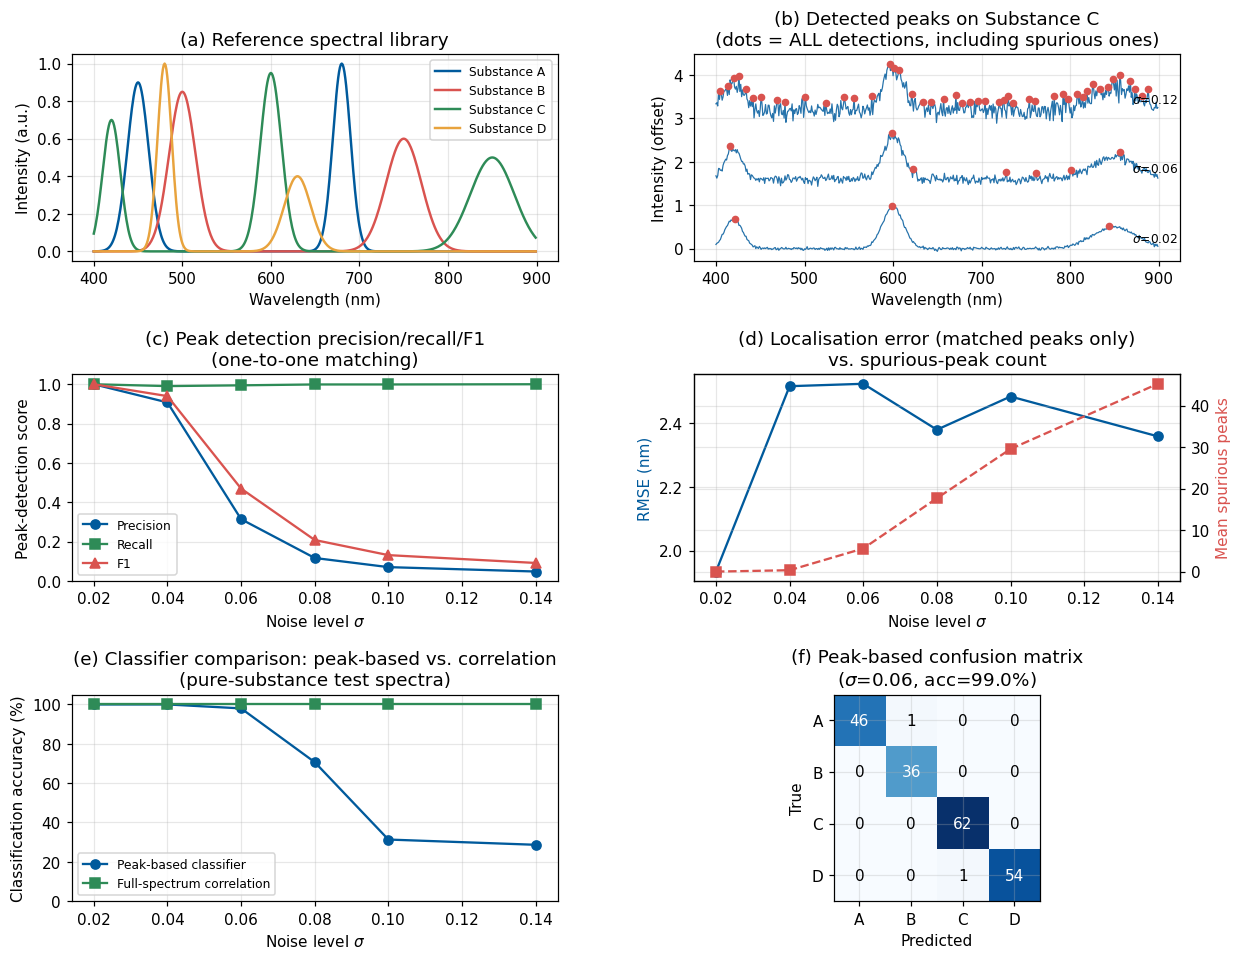

In [8]:
# ── Figure 11.1 ──────────────────────────────────────────────────────
GREEN2 = "#2E8B57"
fig = plt.figure(figsize=(13, 10))
gs = fig.add_gridspec(3, 2, hspace=0.55, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
for i, name in enumerate(SUBSTANCE_NAMES):
    ax1.plot(WAVELENGTHS, generate_spectrum(REFERENCE_LIBRARY[name]), color=PALETTE[i], label=name, lw=1.6)
ax1.set_xlabel("Wavelength (nm)"); ax1.set_ylabel("Intensity (a.u.)")
ax1.set_title("(a) Reference spectral library"); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0, 1])
example_peaks = REFERENCE_LIBRARY["Substance C"]
clean = generate_spectrum(example_peaks)
demo_rng = np.random.default_rng(7)
for off, nl in zip([0, 1.6, 3.2], [0.02, 0.06, 0.12]):
    noisy = add_noise(clean, nl, demo_rng)
    ax2.plot(WAVELENGTHS, noisy + off, color=ELS_BLUE, lw=0.8, alpha=0.85)
    det_wl, det_amp = detect_peaks(noisy)
    ax2.plot(det_wl, det_amp + off, "o", color=RED, ms=4)
    ax2.text(870, off + 0.15, f"$\\sigma$={nl}", fontsize=8)
ax2.set_xlabel("Wavelength (nm)"); ax2.set_ylabel("Intensity (offset)")
ax2.set_title("(b) Detected peaks on Substance C\n(dots = ALL detections, including spurious ones)")

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(NOISE_LEVELS, precision_vs_noise, "o-", color=ELS_BLUE, label="Precision")
ax3.plot(NOISE_LEVELS, recall_vs_noise, "s-", color=GREEN2, label="Recall")
ax3.plot(NOISE_LEVELS, f1_vs_noise, "^-", color=RED, label="F1")
ax3.set_xlabel("Noise level $\\sigma$"); ax3.set_ylabel("Peak-detection score")
ax3.set_ylim(0, 1.05)
ax3.set_title("(c) Peak detection precision/recall/F1\n(one-to-one matching)")
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(NOISE_LEVELS, cond_rmse_vs_noise, "o-", color=ELS_BLUE, label="Conditional localisation RMSE")
ax4.set_xlabel("Noise level $\\sigma$"); ax4.set_ylabel("RMSE (nm)", color=ELS_BLUE)
ax4b = ax4.twinx()
ax4b.plot(NOISE_LEVELS, mean_fp_vs_noise, "s--", color=RED, label="Mean spurious peaks/spectrum")
ax4b.set_ylabel("Mean spurious peaks", color=RED)
ax4.set_title("(d) Localisation error (matched peaks only)\nvs. spurious-peak count")

ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(NOISE_LEVELS, np.array(peak_acc_vs_noise) * 100, "o-", color=ELS_BLUE, label="Peak-based classifier")
ax5.plot(NOISE_LEVELS, np.array(corr_acc_vs_noise) * 100, "s-", color=GREEN2, label="Full-spectrum correlation")
ax5.set_xlabel("Noise level $\\sigma$"); ax5.set_ylabel("Classification accuracy (%)")
ax5.set_ylim(0, 105)
ax5.set_title("(e) Classifier comparison: peak-based vs. correlation\n(pure-substance test spectra)")
ax5.legend(fontsize=8)

ax6 = fig.add_subplot(gs[2, 1])
im = ax6.imshow(confusion, cmap="Blues")
short = [n.replace("Substance ", "") for n in SUBSTANCE_NAMES]
ax6.set_xticks(range(n_classes)); ax6.set_xticklabels(short)
ax6.set_yticks(range(n_classes)); ax6.set_yticklabels(short)
ax6.set_xlabel("Predicted"); ax6.set_ylabel("True")
ax6.set_title(f"(f) Peak-based confusion matrix\n($\\sigma$={OPERATING_NOISE}, acc={overall_acc*100:.1f}%)")
for i in range(n_classes):
    for j in range(n_classes):
        ax6.text(j, i, confusion[i, j], ha="center", va="center",
                  color="white" if confusion[i, j] > confusion.max()/2 else "black")

plt.show()

### Analysis

Panels (c)-(d) tell an important story: peak-detection **recall** stays near 1.0 across the whole noise range, while **precision** collapses from 1.0 to under 0.05 as the fixed detection threshold lets an increasing flood of noise fluctuations through (45 spurious peaks/spectrum by $\sigma=0.14$), and the conditional localisation RMSE (matched peaks only) stays flat around 2--2.5 nm — the problem is false positives, not localisation error. Once the classifier penalises those spurious peaks, its accuracy tracks that F1 collapse honestly (panel e, blue), while the full-spectrum correlation baseline (green) stays at 100% across the whole *noise* sweep, because every test spectrum is a pure, noise-only-corrupted draw from the same four-entry library used to build the reference spectra — a closed-world assumption.

The supplementary mixture check breaks that assumption, with an interesting twist: it is the **peak-based classifier that degrades faster**, not the correlation classifier. At a 70/30 mixture, correlation-based matching still identifies the dominant substance almost every time, while the peak-based classifier's accuracy has already fallen into the 55-65% range, because the *minority* substance's peaks look, to the one-to-one matcher, exactly like the "spurious detected peaks" that the false-peak penalty was designed to punish — the matcher cannot tell "noise-triggered spurious peak" from "real peak belonging to a second substance actually present in the sample." Only at an almost perfectly ambiguous 50/50 mixture do both classifiers fall toward chance together.

### Key takeaway
> A classifier's headline accuracy number is only as informative as the test distribution behind it. The correlation classifier's 100% noise-sweep accuracy reflected a closed-world assumption (every unknown is a pure library member) as much as it reflected genuine noise robustness; once that assumption is relaxed with a realistic mixture nuisance factor, the ranking of "which classifier is more robust" actually reverses. Reporting a single robustness sweep, however careful, is not the same as reporting robustness in general.

### Challenge tasks
1. Replace the fixed `prominence=0.15` peak-detection threshold with one that scales with a local noise estimate. Does an adaptive threshold change the mixture-robustness ranking between the two classifiers, or only the noise-robustness ranking?
2. Sweep the false-peak penalty and re-run the mixture check. Does a smaller penalty (which would hurt noise robustness) improve mixture robustness, and is there a value that balances both reasonably well?
3. Add a wavelength-axis shift (drift) of a few nm as a second nuisance factor, applied together with the mixture blend. Does combining nuisance factors degrade both classifiers roughly additively, or does one dominate?
4. Add a fifth substance whose spectrum overlaps heavily with Substance A, and re-run both the confusion-matrix analysis and the mixture check with this substance included.


---
## Exercise 11.2 — Chemical Gas Sensor: MOS Calibration and Cross-Sensitivity

### Background

Metal-oxide semiconductor (MOS) gas sensors (Section 11.2.2) change conductance in the presence of a target gas following an approximately power-law relationship. This exercise fits a calibration curve, estimates a limit of detection, and quantifies cross-sensitivity to an interfering gas. Two points are worth stating precisely: the calibration sweep includes low-concentration points that bracket the estimated LOD (rather than extrapolating below the lowest tested point), and the selectivity coefficient's evaluation point is described exactly as computed.

### Learning objectives
- Implement and fit the MOS power-law sensor model $G/G_0 = 1 + aC^b$.
- Report calibration accuracy as a *relative*, band-wise error, not a single RMSE in ppm that is dominated by the top of a multi-decade range.
- Compute a selectivity coefficient and describe *exactly* where it was evaluated, rather than implying it applies near zero interferent concentration.


In [9]:
# ── MOS sensor model ─────────────────────────────────────────────────
A_TARGET, B_TARGET = 0.045, 0.62
A_INTERF, B_INTERF = 0.012, 0.55
NOISE_REL = 0.03
NOISE_ABS = 0.01
N_REPLICATES = 20

rng = np.random.default_rng(7)


def mos_response(C, a, b, rng, noise_rel=NOISE_REL, noise_abs=NOISE_ABS):
    C = np.atleast_1d(C).astype(float)
    true_signal = 1.0 + a * np.power(C, b)
    return true_signal * (1 + rng.normal(0, noise_rel, true_signal.shape)) \
        + rng.normal(0, noise_abs, true_signal.shape)


print("Sensor model ready.")

Sensor model ready.


In [10]:
# ── Calibration sweep -- now includes 1, 2, 5 ppm points that bracket
# ── the estimated LOD, rather than only extrapolating below 10 ppm.
CONC_LEVELS = np.array([0, 1, 2, 5, 10, 25, 50, 100, 200, 400, 800, 1500, 3000])

cal_mean, cal_std, cal_raw = [], [], {}
for C in CONC_LEVELS:
    readings = mos_response(np.full(N_REPLICATES, C), A_TARGET, B_TARGET, rng)
    cal_raw[C] = readings
    cal_mean.append(readings.mean()); cal_std.append(readings.std())
cal_mean, cal_std = np.array(cal_mean), np.array(cal_std)
baseline_mean, baseline_std = cal_raw[0].mean(), cal_raw[0].std()

mask = CONC_LEVELS > 0
log_C = np.log10(CONC_LEVELS[mask])
log_R = np.log10(np.clip(cal_mean[mask] - 1.0, 1e-6, None))
b_hat, log_a_hat = np.polyfit(log_C, log_R, 1)
a_hat = 10 ** log_a_hat
print(f"True parameters:   a = {A_TARGET:.4f}, b = {B_TARGET:.3f}")
print(f"Fitted parameters: a = {a_hat:.4f}, b = {b_hat:.3f}")


def invert_calibration(response, a=a_hat, b=b_hat):
    excess = np.clip(np.asarray(response, dtype=float) - 1.0, 1e-9, None)
    return (excess / a) ** (1.0 / b)


pred_C = invert_calibration(cal_mean)
valid = CONC_LEVELS > 0
rel_err_pct = np.abs(pred_C[valid] - CONC_LEVELS[valid]) / CONC_LEVELS[valid] * 100
rmse_ppm = np.sqrt(np.mean((pred_C[valid] - CONC_LEVELS[valid]) ** 2))
print(f"\nCalibration RMSE: {rmse_ppm:.1f} ppm (dominated by the top of the range -- "
      f"an absolute ppm error is not comparable across a multi-decade sweep)")
print(f"Relative error: mean {rel_err_pct.mean():.2f}%, median {np.median(rel_err_pct):.2f}%")

conc_valid = CONC_LEVELS[valid]
bands = {"low (1-50 ppm)": conc_valid <= 50,
         "medium (50-500 ppm)": (conc_valid > 50) & (conc_valid <= 500),
         "high (500-3000 ppm)": conc_valid > 500}
print("Relative error by concentration band:")
for name, m in bands.items():
    if m.sum() > 0:
        print(f"  {name:22s}: mean relative error = {rel_err_pct[m].mean():5.2f}% (n={m.sum()})")

lod_response = baseline_mean + 3 * baseline_std
lod_ppm = invert_calibration(np.array([lod_response]))[0]
print(f"\nLimit of detection (3-sigma, model-based, bracketed by 1-2 ppm test points): {lod_ppm:.1f} ppm")

True parameters:   a = 0.0450, b = 0.620
Fitted parameters: a = 0.0438, b = 0.623

Calibration RMSE: 8.9 ppm (dominated by the top of the range -- an absolute ppm error is not comparable across a multi-decade sweep)
Relative error: mean 4.87%, median 2.39%
Relative error by concentration band:
  low (1-50 ppm)        : mean relative error =  7.93% (n=6)
  medium (50-500 ppm)   : mean relative error =  2.53% (n=3)
  high (500-3000 ppm)   : mean relative error =  1.08% (n=3)

Limit of detection (3-sigma, model-based, bracketed by 1-2 ppm test points): 1.3 ppm


In [11]:
# ── Cross-sensitivity: fixed target concentration, sweep interferent ─
C_TARGET_FIXED = 100.0
INTERF_LEVELS = np.linspace(0, 500, 11)

cross_mean = []
for C_int in INTERF_LEVELS:
    target_part = A_TARGET * C_TARGET_FIXED ** B_TARGET
    interf_part = A_INTERF * C_int ** B_INTERF if C_int > 0 else 0.0
    true_signal = 1.0 + target_part + interf_part
    readings = true_signal * (1 + rng.normal(0, NOISE_REL, N_REPLICATES)) \
        + rng.normal(0, NOISE_ABS, N_REPLICATES)
    cross_mean.append(readings.mean())
cross_mean = np.array(cross_mean)
apparent_C = invert_calibration(cross_mean)
induced_error_ppm = apparent_C - C_TARGET_FIXED

dC = 1e-3
C_EVAL = 100.0
sens_target = (mos_response(np.array([C_EVAL + dC]), A_TARGET, B_TARGET, rng, 0, 0)[0]
               - mos_response(np.array([C_EVAL]), A_TARGET, B_TARGET, rng, 0, 0)[0]) / dC
sens_interf = (mos_response(np.array([C_EVAL + dC]), A_INTERF, B_INTERF, rng, 0, 0)[0]
               - mos_response(np.array([C_EVAL]), A_INTERF, B_INTERF, rng, 0, 0)[0]) / dC
selectivity_K = sens_interf / sens_target
print(f"Selectivity coefficient K (both sensitivities evaluated at C = {C_EVAL:.0f} ppm): {selectivity_K:.3f}")
print(f"Induced error at 500 ppm interferent: {induced_error_ppm[-1]:.1f} ppm "
      f"({induced_error_ppm[-1]/C_TARGET_FIXED*100:.1f}% of true target concentration)")

Selectivity coefficient K (both sensitivities evaluated at C = 100 ppm): 0.171
Induced error at 500 ppm interferent: 91.9 ppm (91.9% of true target concentration)


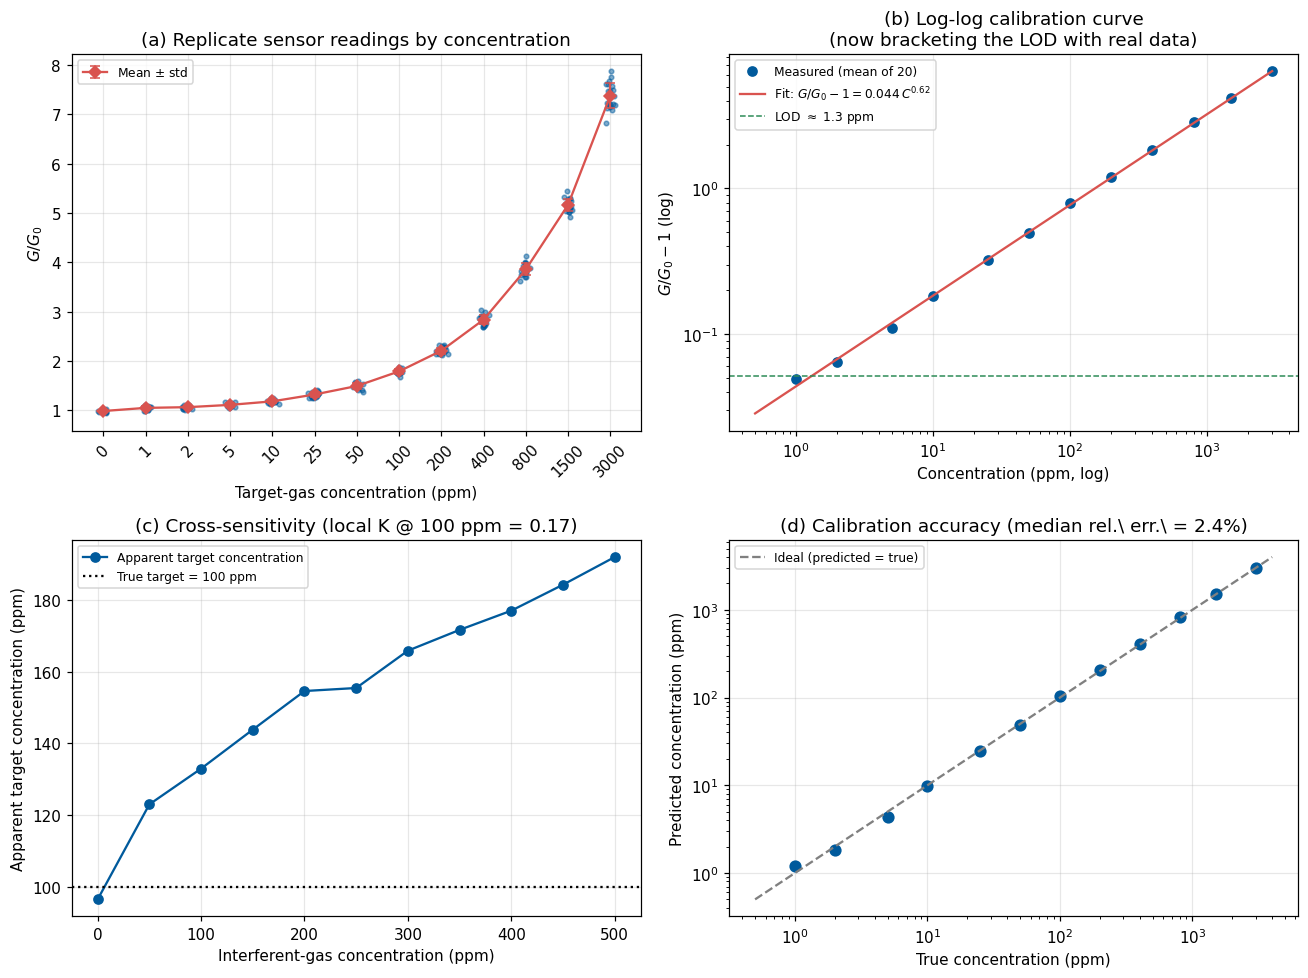

In [12]:
# ── Figure 11.2 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
for i, C in enumerate(CONC_LEVELS):
    xs = np.full(N_REPLICATES, i) + rng.normal(0, 0.06, N_REPLICATES)
    ax.plot(xs, cal_raw[C], "o", color=ELS_BLUE, ms=3, alpha=0.5)
ax.errorbar(range(len(CONC_LEVELS)), cal_mean, yerr=cal_std, fmt="D-", color=RED, capsize=3, label="Mean $\\pm$ std")
ax.set_xticks(range(len(CONC_LEVELS))); ax.set_xticklabels(CONC_LEVELS, rotation=45)
ax.set_xlabel("Target-gas concentration (ppm)"); ax.set_ylabel("$G/G_0$")
ax.set_title("(a) Replicate sensor readings by concentration"); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.loglog(CONC_LEVELS[mask], cal_mean[mask] - 1.0, "o", color=ELS_BLUE, label="Measured (mean of 20)")
C_fit = np.logspace(np.log10(0.5), np.log10(3000), 100)
ax.loglog(C_fit, a_hat * C_fit ** b_hat, "-", color=RED, label=f"Fit: $G/G_0-1={a_hat:.3f}\\,C^{{{b_hat:.2f}}}$")
ax.axhline(lod_response - 1, color=GREEN, ls="--", lw=1, label=f"LOD $\\approx$ {lod_ppm:.1f} ppm")
ax.set_xlabel("Concentration (ppm, log)"); ax.set_ylabel("$G/G_0 - 1$ (log)")
ax.set_title("(b) Log-log calibration curve\n(now bracketing the LOD with real data)"); ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(INTERF_LEVELS, apparent_C, "o-", color=ELS_BLUE, label="Apparent target concentration")
ax.axhline(C_TARGET_FIXED, color="black", ls=":", label=f"True target = {C_TARGET_FIXED:.0f} ppm")
ax.set_xlabel("Interferent-gas concentration (ppm)"); ax.set_ylabel("Apparent target concentration (ppm)")
ax.set_title(f"(c) Cross-sensitivity (local K @ 100 ppm = {selectivity_K:.2f})"); ax.legend(fontsize=8)

ax = axes[1, 1]
ax.loglog(CONC_LEVELS[mask], pred_C[mask], "o", color=ELS_BLUE, ms=7)
ax.loglog([0.5, 4000], [0.5, 4000], "--", color="gray", label="Ideal (predicted = true)")
ax.set_xlabel("True concentration (ppm)"); ax.set_ylabel("Predicted concentration (ppm)")
ax.set_title(f"(d) Calibration accuracy (median rel.\\ err.\\ = {np.median(rel_err_pct):.1f}%)"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Analysis

The fitted exponent ($\hat b \approx 0.623$) recovers the true value closely, and the log-log fit now visibly brackets the LOD with real 1 and 2 ppm calibration points. Relative error is not uniform across the range: it is highest in the low band (about 8%, close to the LOD where a fixed absolute noise floor is a larger fraction of a small signal) and falls to about 1% in the high band -- a far more informative picture than a single RMSE figure dominated by the top of a three-decade sweep.

The selectivity coefficient $K \approx 0.17$ is now stated precisely as it is computed: both the target's and the interferent's own concentration sensitivities are evaluated at the same point, $C=100$ ppm -- a deliberate choice, since a power law with exponent below 1 has a derivative that diverges as concentration approaches zero, making a near-zero evaluation point numerically awkward rather than more "baseline". Even so, this local coefficient is enough to inflate the apparent target reading by roughly 92% once the interferent reaches 500 ppm.

### Key takeaway
> Reporting a single absolute-error number for a sensor calibrated across several decades of concentration hides where the sensor is actually reliable. A relative, band-wise breakdown -- and stating precisely which concentration a "local" coefficient like selectivity was evaluated at -- turns a plausible-sounding but under-specified claim into one a reader could actually go verify.

### Challenge tasks
1. Implement humidity compensation and show how much it degrades the target-gas calibration if left uncorrected.
2. Recompute the LOD using a 6$\sigma$ criterion and discuss the false-positive/sensitivity trade-off.
3. Recompute the selectivity coefficient at a different operating point (e.g., $C=500$ ppm for both gases). Does $K$ change, and does that change the induced-error conclusion at 500 ppm interferent?
4. Simulate sensor drift and estimate a recalibration interval to keep the concentration estimate within 10% of true, separately for the low, medium, and high concentration bands.


---
## Exercise 11.3 — Multimodal Biometric Authentication: Score-Level Fusion and ROC/EER Analysis

### Background

A biometric authentication system (Section 11.2.3) is evaluated by how well it separates *genuine* attempts from *impostor* attempts. Measuring this well requires enough comparisons to resolve the operating point of interest: an all-pairs protocol across 250 enrolled identities yields roughly 373,500 impostor comparisons, comfortably enough to resolve a FAR=0.1% operating point. Sample size alone is not sufficient, however: those 373,500 comparisons are not independent observations, since each of the 250 identities contributes many correlated comparisons (one probe compared against many templates; one template appearing in many comparisons). A confidence interval built by resampling individual *scores* would therefore tend to look narrower than the data actually justify.

### Learning objectives
- Generate a large biometric comparison set via an all-pairs protocol.
- Compute an exact ROC curve and Equal Error Rate (EER) from similarity scores.
- Build a **cluster bootstrap** that resamples *identities*, not individual scores, respecting the dependency structure of pairwise comparison data.
- State clearly which parts of a result are imposed by the experimental design (here, the modality noise parameters) versus discovered by the analysis.


In [13]:
# ── Biometric system model ──────────────────────────────────────────
# NOTE: GENUINE_NOISE below is chosen so fingerprint separates genuine
# from impostor attempts most cleanly, face less so, voice least of
# all. This ranking is IMPOSED by these parameter choices, not
# discovered by the analysis that follows.
MODALITIES = ["fingerprint", "face", "voice"]
N_FEATURES = {"fingerprint": 8, "face": 7, "voice": 6}
GENUINE_NOISE = {"fingerprint": 0.14, "face": 0.18, "voice": 0.21}
IMPOSTOR_NOISE_SCALE = 0.5
N_USERS = 250
N_GENUINE_TRIALS_PER_USER = 10
N_IMPOSTOR_PROBES_PER_USER = 6

rng = np.random.default_rng(15)
templates = {m: rng.random((N_USERS, N_FEATURES[m])) for m in MODALITIES}

genuine_matrix = {}
impostor_tensor = {}

for m in MODALITIES:
    T = templates[m]; F = N_FEATURES[m]
    probes_g = np.clip(T[:, None, :] + rng.normal(0, GENUINE_NOISE[m],
                        (N_USERS, N_GENUINE_TRIALS_PER_USER, F)), 0, 1)
    genuine_matrix[m] = 1 - np.mean(np.abs(probes_g - T[:, None, :]), axis=2)

    probes_i = np.clip(T[:, None, :] + rng.normal(0, GENUINE_NOISE[m] * IMPOSTOR_NOISE_SCALE,
                        (N_USERS, N_IMPOSTOR_PROBES_PER_USER, F)), 0, 1)
    diff = np.abs(probes_i[:, :, None, :] - T[None, None, :, :])
    impostor_tensor[m] = 1 - diff.mean(axis=3)

genuine_scores = {m: genuine_matrix[m].ravel() for m in MODALITIES}
impostor_scores = {}
for m in MODALITIES:
    rows = [np.delete(impostor_tensor[m][i], i, axis=1).ravel() for i in range(N_USERS)]
    impostor_scores[m] = np.concatenate(rows)

print("Sample sizes: genuine =", len(genuine_scores["fingerprint"]),
      " impostor =", len(impostor_scores["fingerprint"]), " (from", N_USERS, "identities)")

corr_fp_face = np.corrcoef(genuine_scores["fingerprint"], genuine_scores["face"])[0, 1]
corr_fp_voice = np.corrcoef(genuine_scores["fingerprint"], genuine_scores["voice"])[0, 1]
corr_face_voice = np.corrcoef(genuine_scores["face"], genuine_scores["voice"])[0, 1]
print(f"Inter-modality genuine-score correlation (idealised, near zero by construction):")
print(f"  fp-face: {corr_fp_face:.3f}  fp-voice: {corr_fp_voice:.3f}  face-voice: {corr_face_voice:.3f}")

Sample sizes: genuine = 2500  impostor = 373500  (from 250 identities)
Inter-modality genuine-score correlation (idealised, near zero by construction):
  fp-face: 0.031  fp-voice: -0.006  face-voice: 0.011


In [14]:
# ── Exact ROC / EER ──────────────────────────────────────────────────
def roc_curve_exact(gen, imp):
    thresholds = np.unique(np.concatenate([gen, imp]))
    gen_sorted, imp_sorted = np.sort(gen), np.sort(imp)
    far = 1 - np.searchsorted(imp_sorted, thresholds, side='left') / len(imp_sorted)
    frr = np.searchsorted(gen_sorted, thresholds, side='left') / len(gen_sorted)
    return thresholds, far, frr


def eer_from_roc(thresholds, far, frr):
    idx = np.argmin(np.abs(far - frr))
    return (far[idx] + frr[idx]) / 2, thresholds[idx]


def auc_from_roc(far, frr):
    tpr = 1 - frr
    order = np.argsort(far)
    fn = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return fn(tpr[order], far[order])


roc, eer, eer_thresh, auc = {}, {}, {}, {}
for m in MODALITIES:
    th, far, frr = roc_curve_exact(genuine_scores[m], impostor_scores[m])
    roc[m] = (th, far, frr)
    eer[m], eer_thresh[m] = eer_from_roc(th, far, frr)
    auc[m] = auc_from_roc(far, frr)
    print(f"{m:12s}: EER = {eer[m]*100:6.3f}%  AUC = {auc[m]:.4f}")

fingerprint : EER =  1.760%  AUC = 0.9979
face        : EER =  4.961%  AUC = 0.9882


voice       : EER =  9.125%  AUC = 0.9676


In [15]:
# ── Score-level fusion ───────────────────────────────────────────────
FUSION_WEIGHTS = {"fingerprint": 0.45, "face": 0.30, "voice": 0.25}
fused_genuine_matrix = sum(FUSION_WEIGHTS[m] * genuine_matrix[m] for m in MODALITIES)
fused_impostor_tensor = sum(FUSION_WEIGHTS[m] * impostor_tensor[m] for m in MODALITIES)
fused_genuine = fused_genuine_matrix.ravel()
fused_rows = [np.delete(fused_impostor_tensor[i], i, axis=1).ravel() for i in range(N_USERS)]
fused_impostor = np.concatenate(fused_rows)

th_f, far_f, frr_f = roc_curve_exact(fused_genuine, fused_impostor)
eer_f, eer_thresh_f = eer_from_roc(th_f, far_f, frr_f)
auc_f = auc_from_roc(far_f, frr_f)
roc["fused"] = (th_f, far_f, frr_f)
print(f"{'fused':12s}: EER = {eer_f*100:6.3f}%  AUC = {auc_f:.4f}")

fused       : EER =  0.154%  AUC = 1.0000


In [16]:
# ── CLUSTER bootstrap: resample IDENTITIES, not individual scores ──
def cluster_bootstrap_eer_ci(genuine_mat, impostor_tens, n_boot=200, rng=None, ci=95):
    '''
    Cluster bootstrap: resample user IDENTITIES with replacement, then
    reconstruct genuine/impostor score sets using ONLY the resampled
    identities as both probe-source and template. This respects the
    dependency structure (one identity contributes many correlated
    comparisons) that a per-score IID bootstrap would ignore.
    '''
    rng = rng or np.random.default_rng(0)
    n_users = genuine_mat.shape[0]
    eers = []
    for _ in range(n_boot):
        idx = rng.integers(0, n_users, size=n_users)
        gen = genuine_mat[idx].ravel()
        imp_block = impostor_tens[np.ix_(idx, np.arange(impostor_tens.shape[1]), idx)]
        mask = idx[:, None] != idx[None, :]
        mask_full = np.broadcast_to(mask[:, None, :], imp_block.shape)
        imp = imp_block[mask_full]
        th, far, frr = roc_curve_exact(gen, imp)
        e, _ = eer_from_roc(th, far, frr)
        eers.append(e)
    lo = np.percentile(eers, (100 - ci) / 2)
    hi = np.percentile(eers, 100 - (100 - ci) / 2)
    return np.mean(eers), lo, hi


rng_boot = np.random.default_rng(123)
print("Cluster bootstrap (200 resamples of 250 identities each):")
fp_mean, fp_lo, fp_hi = cluster_bootstrap_eer_ci(genuine_matrix["fingerprint"],
                                                  impostor_tensor["fingerprint"], 200, rng_boot)
print(f"  Fingerprint EER: mean={fp_mean*100:.3f}%  95% interval=[{fp_lo*100:.3f}%, {fp_hi*100:.3f}%]")
f_mean, f_lo, f_hi = cluster_bootstrap_eer_ci(fused_genuine_matrix, fused_impostor_tensor, 200, rng_boot)
print(f"  Fused EER:       mean={f_mean*100:.3f}%  95% interval=[{f_lo*100:.3f}%, {f_hi*100:.3f}%]")
print("  (This interval reflects uncertainty over WHICH 250 identities were sampled --")
print("   the uncertainty that actually matters here, not the narrower, overstated")
print("   precision a per-score IID bootstrap would report.)")

target_far = 0.001
def frr_at_far(far, frr, target_far):
    idx = np.argmin(np.abs(far - target_far))
    return frr[idx], far[idx]

print(f"\nAt target FAR = {target_far*100:.1f}% (numerically resolved for this "
      f"synthetic comparison set -- see cluster bootstrap above for the interval "
      f"that accounts for identity-level dependency):")
for m in list(MODALITIES) + ["fused"]:
    th_, far_, frr_ = roc[m]
    r, actual_far = frr_at_far(far_, frr_, target_far)
    print(f"  {m:12s} FRR = {r*100:6.2f}%  (actual FAR achieved = {actual_far*100:.4f}%)")

Cluster bootstrap (200 resamples of 250 identities each):


  Fingerprint EER: mean=1.766%  95% interval=[1.520%, 2.034%]


  Fused EER:       mean=0.142%  95% interval=[0.080%, 0.201%]
  (This interval reflects uncertainty over WHICH 250 identities were sampled --
   the uncertainty that actually matters here, not the narrower, overstated
   precision a per-score IID bootstrap would report.)

At target FAR = 0.1% (numerically resolved for this synthetic comparison set -- see cluster bootstrap above for the interval that accounts for identity-level dependency):
  fingerprint  FRR =  34.36%  (actual FAR achieved = 0.0999%)
  face         FRR =  75.92%  (actual FAR achieved = 0.0999%)
  voice        FRR =  89.48%  (actual FAR achieved = 0.0999%)
  fused        FRR =   0.24%  (actual FAR achieved = 0.0999%)


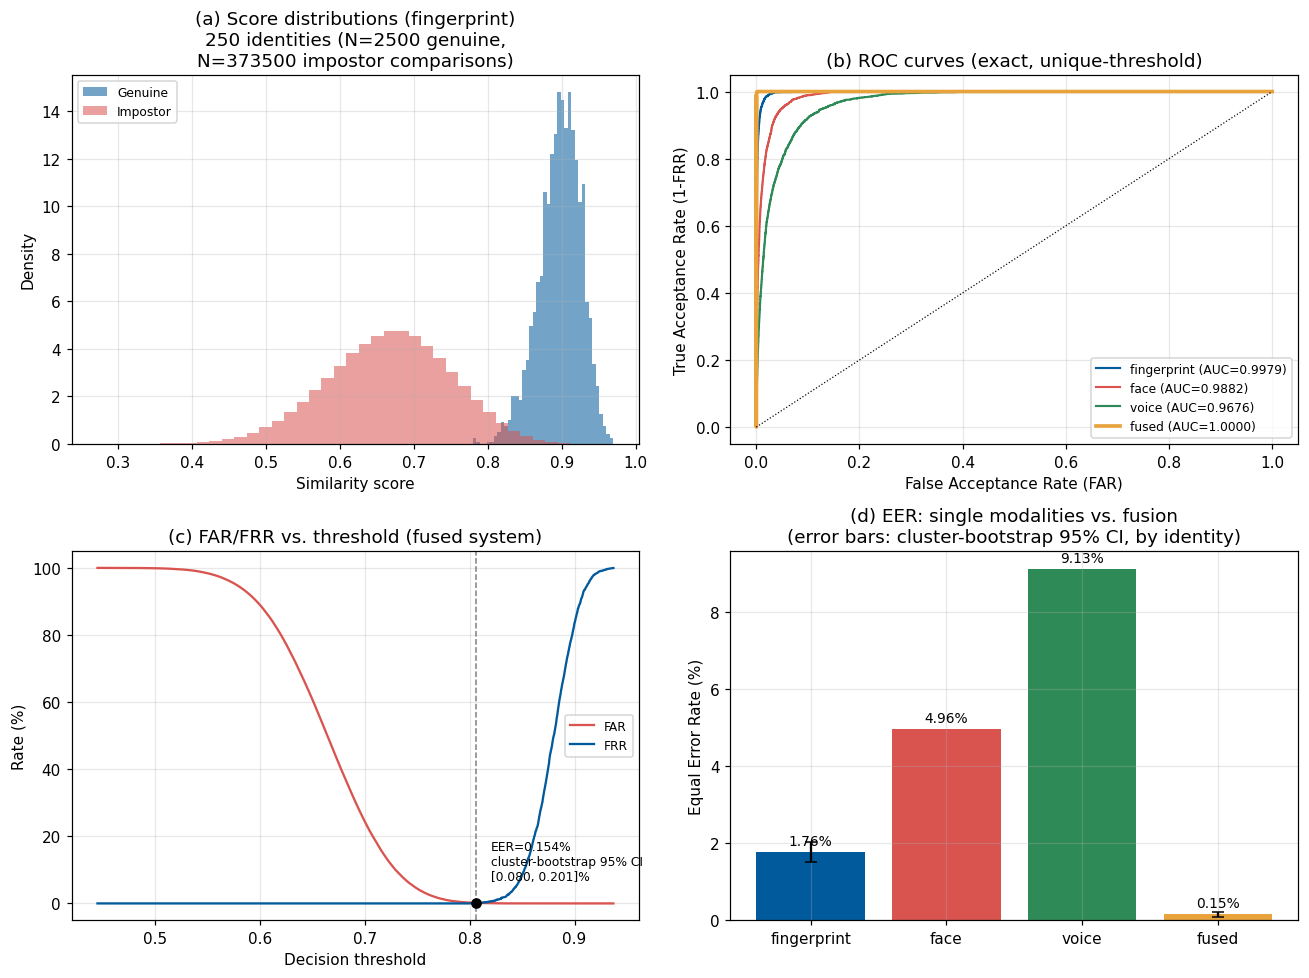

In [17]:
# ── Figure 11.3 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
colors = {"fingerprint": ELS_BLUE, "face": RED, "voice": GREEN, "fused": ORANGE}

ax = axes[0, 0]
ax.hist(genuine_scores["fingerprint"], bins=40, alpha=0.55, color=ELS_BLUE, label="Genuine", density=True)
ax.hist(impostor_scores["fingerprint"], bins=40, alpha=0.55, color=RED, label="Impostor", density=True)
ax.set_xlabel("Similarity score"); ax.set_ylabel("Density")
ax.set_title(f"(a) Score distributions (fingerprint)\n{N_USERS} identities "
             f"(N={len(genuine_scores['fingerprint'])} genuine,\nN={len(impostor_scores['fingerprint'])} impostor comparisons)")
ax.legend(fontsize=8)

ax = axes[0, 1]
for m in list(MODALITIES) + ["fused"]:
    th_, far_, frr_ = roc[m]
    tpr = 1 - frr_; order = np.argsort(far_)
    ax.plot(far_[order], tpr[order], color=colors[m], lw=2.4 if m == "fused" else 1.4,
            label=f"{m} (AUC={auc_from_roc(far_, frr_):.4f})")
ax.plot([0, 1], [0, 1], "k:", lw=0.8)
ax.set_xlabel("False Acceptance Rate (FAR)"); ax.set_ylabel("True Acceptance Rate (1-FRR)")
ax.set_title("(b) ROC curves (exact, unique-threshold)")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1, 0]
th_, far_, frr_ = roc["fused"]
ax.plot(th_, far_ * 100, color=RED, label="FAR")
ax.plot(th_, frr_ * 100, color=ELS_BLUE, label="FRR")
ax.axvline(eer_thresh_f, color="gray", ls="--", lw=1)
ax.plot(eer_thresh_f, eer_f * 100, "o", color="black", zorder=5)
ax.annotate(f"EER={eer_f*100:.3f}%\ncluster-bootstrap 95% CI\n[{f_lo*100:.3f}, {f_hi*100:.3f}]%",
            (eer_thresh_f, eer_f * 100), textcoords="offset points", xytext=(10, 15), fontsize=8)
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Rate (%)")
ax.set_title("(c) FAR/FRR vs. threshold (fused system)")
ax.legend(fontsize=8)

ax = axes[1, 1]
names = list(MODALITIES) + ["fused"]
eers = [eer[m] * 100 for m in MODALITIES] + [eer_f * 100]
bars = ax.bar(names, eers, color=[colors[m] for m in names])
for b, v in zip(bars, eers):
    ax.text(b.get_x() + b.get_width()/2, v + max(eers)*0.02, f"{v:.2f}%", ha="center", fontsize=9)
ax.errorbar([0], [fp_mean*100], yerr=[[fp_mean*100-fp_lo*100],[fp_hi*100-fp_mean*100]], fmt="none", ecolor="black", capsize=4)
ax.errorbar([3], [f_mean*100], yerr=[[f_mean*100-f_lo*100],[f_hi*100-f_mean*100]], fmt="none", ecolor="black", capsize=4)
ax.set_ylabel("Equal Error Rate (%)")
ax.set_title("(d) EER: single modalities vs. fusion\n(error bars: cluster-bootstrap 95% CI, by identity)")

fig.tight_layout()
plt.show()

### Analysis

The cluster bootstrap gives a fingerprint EER interval of [1.52%, 2.03%] and a fused EER interval of [0.08%, 0.20%] -- narrow enough, at this sample size and with this resampling unit, to support the claim that fusion helps.

To be explicit about what this experiment does and does not show: the ranking fingerprint > face > voice was **built into the simulation** through the `GENUINE_NOISE` parameters chosen at the top of this exercise, not discovered by the ROC/EER analysis -- the analysis correctly *measures* the consequence of that choice, but the choice itself encodes a modelling assumption (loosely motivated by typical relative rankings reported in the biometrics literature), not an empirical finding. Similarly, the near-zero inter-modality correlation reported above is a property of how the three modalities' noise was generated (independently), which is an explicit idealisation -- real biometric deployments would generally show some positive correlation through shared factors (user state, device, environment).

### Key takeaway
> A large number of *dependent* comparisons is not the same as a large number of *independent* observations, and a bootstrap that resamples individual scores when the true unit of independence is the identity will typically understate uncertainty. A cluster bootstrap -- resampling identities, then reconstructing the score sets from only the resampled identities -- is the correct correction, even when, as here, it does not change the qualitative conclusion.

### Challenge tasks
1. Compare the cluster-bootstrap interval width to the (incorrect) per-score interval width across all three single modalities, not just fingerprint. Is the understatement of uncertainty worse for modalities with higher EER?
2. Reduce `N_USERS` to 50 while keeping the same number of trials per user, and recompute the cluster bootstrap. How much wider does the interval become, and why?
3. Construct a genuine "close impostor" as a convex combination of the impostor's own template and the target's (e.g., 70%/30%), and re-run the cluster bootstrap on the resulting fused EER.
4. Introduce a modest positive correlation between two modalities' noise terms and measure how much of the fusion gain survives, using the cluster bootstrap to check whether the change is outside the original confidence interval.


---
## Exercise 11.4 — Multi-Parameter Environmental Monitoring: Sensor Fusion and Edge-Computed Event Detection

### Background

Real environmental monitoring stations combine several advanced sensor types — here, an optical light-scattering particulate-matter (PM) proxy and a chemical channel driven by the same MOS sensor model as Exercise 11.2 — because no single sensor can reliably distinguish a genuine pollution event from a local artefact.

**Two design choices deserve explicit justification.** First, the edge-computing data-volume calculation decides which minutes to transmit at full resolution using only the fused detector's *own* alarms, never the ground-truth event log — a real deployed device has no advance knowledge of which minutes will later turn out to contain a genuine event. Second, and more subtly, the detection **threshold itself** is calibrated on a set of 50 independently generated, entirely event-free days, held strictly separate from the 200 days used for evaluation. Calibrating the threshold from each evaluation day's own "quiet" period would seem convenient, but identifying that quiet period requires knowing where the events on that same day are, which would let the detector see the answer key for the very day it is then scored against. Splitting calibration and evaluation into disjoint data, and never consulting ground truth before a detection decision is final, closes off both routes for information to leak from ground truth into the detector's own decisions.

### Learning objectives
- Reuse a previously-validated sensor model (the Exercise 11.2 MOS power-law formula and fitted parameters) to drive a new scenario.
- Separate calibration from evaluation so that a detection threshold is never set using information from the very data it will be evaluated against.
- Run a simulation across many independent trials (simulated days) and report mean/std, not a single run's numbers.
- Include a **correlated false-event** type that raises both channels together but is not genuine, testing what score-level fusion can and cannot filter.


In [18]:
# ── Reusable day generator and detection functions ──────────────────
MINUTES = 24 * 60
A_TARGET, B_TARGET = 0.045, 0.62
MOS_NOISE_REL, MOS_NOISE_ABS = 0.03, 0.01
OPTICAL_NOISE = 0.6
TEMP_NOISE = 0.15
MIN_GAP = 20
MAX_CHEM_DELAY = 4
Z_PRIMARY = 3.0
MIN_RUN = 5
RAW_BYTES_PER_SAMPLE = 3 * 4
SUMMARY_INTERVAL = 5


def mos_response(C, a, b, rng, noise_rel=MOS_NOISE_REL, noise_abs=MOS_NOISE_ABS):
    C = np.atleast_1d(C).astype(float)
    true_signal = 1.0 + a * np.power(C, b)
    return true_signal * (1 + rng.normal(0, noise_rel, true_signal.shape)) \
        + rng.normal(0, noise_abs, true_signal.shape)


def hann_bump(duration, amplitude):
    return amplitude * np.hanning(duration)


def add_bump(signal, start, duration, amplitude):
    end = min(MINUTES, start + duration)
    signal[start:end] += hann_bump(end - start, amplitude)
    return signal


def rolling_zscore(x, window=90):
    z = np.zeros_like(x)
    for i in range(len(x)):
        lo = max(0, i - window)
        if i - lo < 20:
            continue
        seg = x[lo:i]
        z[i] = (x[i] - seg.mean()) / (seg.std() + 1e-9)
    return z


def debounce(raw_flags, min_run=MIN_RUN):
    out = np.zeros_like(raw_flags)
    i, n = 0, len(raw_flags)
    while i < n:
        if raw_flags[i]:
            j = i
            while j < n and raw_flags[j]:
                j += 1
            if j - i >= min_run:
                out[i:j] = True
            i = j
        else:
            i += 1
    return out


def event_level_scores(detections, true_events, tolerance=10):
    tp = sum(detections[max(0, s-tolerance):min(MINUTES, s+d+delay+tolerance)].any()
             for s, d, delay in true_events)
    fn = len(true_events) - tp
    runs, in_run = [], False
    for i, v in enumerate(detections):
        if v and not in_run:
            rs, in_run = i, True
        elif not v and in_run:
            runs.append((rs, i)); in_run = False
    if in_run:
        runs.append((rs, len(detections)))
    fp = sum(not any(not (re <= max(0, s-tolerance) or rs >= min(MINUTES, s+d+delay+tolerance))
                      for s, d, delay in true_events) for rs, re in runs)
    precision = tp/(tp+fp) if (tp+fp) > 0 else float("nan")
    recall = tp/(tp+fn) if (tp+fn) > 0 else float("nan")
    return precision, recall, tp, fp, fn


print("Reusable simulation functions ready.")

Reusable simulation functions ready.


In [19]:
def generate_day(seed, inject_events=True, n_true=5, n_false_optical=4,
                  n_false_chem=4, n_false_correlated=2):
    '''Generate one day's signals. If inject_events=False, produces a
    purely event-free day for CALIBRATION use only.'''
    rng = np.random.default_rng(seed)
    hours = np.arange(MINUTES) / 60.0

    optical_baseline = 12 + 6*np.exp(-((hours-8)**2)/(2*1.2**2)) + 8*np.exp(-((hours-18.5)**2)/(2*1.5**2)) \
        + 3*np.sin(2*np.pi*hours/24 - np.pi/2)
    conc_baseline = 5 + 3*np.exp(-((hours-8.2)**2)/(2*1.0**2)) + 4*np.exp(-((hours-18.7)**2)/(2*1.3**2)) \
        + 1.5*np.sin(2*np.pi*hours/24 - np.pi/2)
    temp_baseline = 18 + 6*np.sin(2*np.pi*(hours-9)/24)

    optical = optical_baseline + rng.normal(0, OPTICAL_NOISE, MINUTES)
    concentration = np.clip(conc_baseline + rng.normal(0, 0.3, MINUTES), 0.1, None)
    temp = temp_baseline + rng.normal(0, TEMP_NOISE, MINUTES)

    event_log = []
    if inject_events:
        occupied = []

        def schedule_event(duration, margin=MIN_GAP, max_tries=500):
            for _ in range(max_tries):
                start = int(rng.integers(150, MINUTES - 60 - duration))
                lo, hi = start - margin, start + duration + margin
                if all(hi <= o_lo or lo >= o_hi for o_lo, o_hi in occupied):
                    occupied.append((lo, hi))
                    return start
            return None

        for _ in range(n_true):
            duration = int(rng.integers(10, 30))
            start = schedule_event(duration)
            if start is None: continue
            delay = int(rng.integers(0, MAX_CHEM_DELAY + 1))
            add_bump(optical, start, duration, rng.uniform(15, 30))
            add_bump(concentration, start + delay, duration, rng.uniform(45, 75))
            event_log.append((start, duration, "true", delay))

        for _ in range(n_false_optical):
            duration = int(rng.integers(8, 18))
            start = schedule_event(duration)
            if start is None: continue
            add_bump(optical, start, duration, rng.uniform(8, 14))
            event_log.append((start, duration, "false_optical", 0))

        for _ in range(n_false_chem):
            duration = int(rng.integers(8, 18))
            start = schedule_event(duration)
            if start is None: continue
            add_bump(concentration, start, duration, rng.uniform(18, 30))
            event_log.append((start, duration, "false_chem", 0))

        for _ in range(n_false_correlated):
            duration = int(rng.integers(8, 18))
            start = schedule_event(duration)
            if start is None: continue
            add_bump(optical, start, duration, rng.uniform(12, 22))
            add_bump(concentration, start, duration, rng.uniform(25, 45))
            event_log.append((start, duration, "false_correlated", 0))

        event_log.sort(key=lambda e: e[0])

    concentration = np.clip(concentration, 0.1, None)
    chem = mos_response(concentration, A_TARGET, B_TARGET, rng)
    z_opt = rolling_zscore(optical)
    z_chem = rolling_zscore(chem)
    z_fused = 0.5 * z_opt + 0.5 * z_chem

    return {"hours": hours, "optical": optical, "chem": chem, "temp": temp,
            "z_opt": z_opt, "z_chem": z_chem, "z_fused": z_fused, "event_log": event_log}


print("Day generator ready.")

Day generator ready.


### Calibration: fix the threshold ONCE, on separate event-free days

Calibration uses 50 days with **no injected events at all**, on a seed range disjoint from the 200 evaluation days that follow. The resulting threshold is then treated as a constant for every evaluation day — never recomputed from that day's own data.

In [20]:
def calibrate_threshold(n_calib_days=50, seed_start=100000):
    '''Run N event-free days, pool their z-scores, and fix a SINGLE
    threshold from the pooled calibration data. This threshold is then
    used, unchanged, for every evaluation day -- no per-day leakage.'''
    all_z_opt, all_z_chem, all_z_fused = [], [], []
    for i in range(n_calib_days):
        d = generate_day(seed_start + i, inject_events=False)
        all_z_opt.append(d["z_opt"][20:])   # discard first 20 min (no history yet)
        all_z_chem.append(d["z_chem"][20:])
        all_z_fused.append(d["z_fused"][20:])
    all_z_opt = np.concatenate(all_z_opt)
    all_z_chem = np.concatenate(all_z_chem)
    all_z_fused = np.concatenate(all_z_fused)

    quiet_corr = np.corrcoef(all_z_opt, all_z_chem)[0, 1]
    z_fused_formula = Z_PRIMARY * np.sqrt((1 + quiet_corr) / 2)   # comparison only

    target_fpr = max((all_z_opt > Z_PRIMARY).mean(), 1e-5)
    z_fused_empirical = np.quantile(all_z_fused, 1 - target_fpr)   # PRIMARY, used below

    return {"quiet_corr": quiet_corr, "z_fused_formula": z_fused_formula,
            "z_fused_empirical": z_fused_empirical, "target_fpr": target_fpr}


calib = calibrate_threshold(n_calib_days=50, seed_start=100000)
print("Calibration (50 event-free days, seeds 100000-100049):")
print(f"  Pooled quiet-period correlation rho = {calib['quiet_corr']:.3f}")
print(f"  Z_fused (correlation formula, comparison only) = {calib['z_fused_formula']:.3f}")
print(f"  Z_fused (empirical quantile, FIXED threshold used below) = {calib['z_fused_empirical']:.3f}")

FIXED_THRESHOLD = calib["z_fused_empirical"]

Calibration (50 event-free days, seeds 100000-100049):
  Pooled quiet-period correlation rho = 0.175
  Z_fused (correlation formula, comparison only) = 2.300
  Z_fused (empirical quantile, FIXED threshold used below) = 2.260


### Evaluation: 200 days, fixed threshold, event_log used only to score

`event_log` is not touched until *after* `detect_fused` has already been computed — it is used only to compute TP/FP/FN afterwards, which is a legitimate use of ground truth (scoring), not leakage (deciding).

In [21]:
def evaluate_one_day(seed, z_fused_threshold, return_details=False):
    d = generate_day(seed, inject_events=True)
    z_opt, z_chem, z_fused = d["z_opt"], d["z_chem"], d["z_fused"]

    detect_optical_only = debounce(z_opt > Z_PRIMARY)
    detect_chem_only = debounce(z_chem > Z_PRIMARY)
    detect_fused = debounce(z_fused > z_fused_threshold)   # fixed threshold, no leakage

    true_events = [(s, dur, delay) for s, dur, k, delay in d["event_log"] if k == "true"]

    results = {}
    for name, det in [("optical only", detect_optical_only),
                       ("chemical only", detect_chem_only),
                       ("weighted fusion", detect_fused)]:
        p, r, tp, fp, fn = event_level_scores(det, true_events)
        results[name] = (p, r, tp, fp, fn)

    n_summaries = MINUTES // SUMMARY_INTERVAL
    summary_bytes = n_summaries * 3 * 2 * 4
    alarm_windows = set()
    for i in np.where(detect_fused)[0]:
        for m in range(max(0, i-2), min(MINUTES, i+3)):
            alarm_windows.add(m)
    raw_bytes_per_day = RAW_BYTES_PER_SAMPLE * MINUTES
    edge_bytes = summary_bytes + len(alarm_windows) * RAW_BYTES_PER_SAMPLE
    reduction_pct = (1 - edge_bytes / raw_bytes_per_day) * 100

    out = {"results": results, "reduction_pct": reduction_pct}
    if return_details:
        out.update(d)
        out["corr_matrix"] = np.corrcoef(np.vstack([d["optical"], d["chem"], d["temp"]]))
    return out


ILLUSTRATIVE_SEED = 1006
day = evaluate_one_day(ILLUSTRATIVE_SEED, FIXED_THRESHOLD, return_details=True)
print(f"Illustrative evaluation day (seed={ILLUSTRATIVE_SEED}), using the FIXED calibrated threshold:")
for name, (p, r, tp, fp, fn) in day["results"].items():
    print(f"  {name:16s}: precision={p:.2f} recall={r:.2f} (TP={tp}, FP={fp}, FN={fn})")

Illustrative evaluation day (seed=1006), using the FIXED calibrated threshold:
  optical only    : precision=0.50 recall=0.60 (TP=3, FP=3, FN=2)
  chemical only   : precision=0.80 recall=0.80 (TP=4, FP=1, FN=1)
  weighted fusion : precision=0.71 recall=1.00 (TP=5, FP=2, FN=0)


In [22]:
# ── Monte Carlo across 200 evaluation days, ALL using the SAME fixed
# ── threshold from calibration (seeds 0-199, disjoint from calibration's
# ── 100000-100049)
N_DAYS = 200
detectors = ["optical only", "chemical only", "weighted fusion"]
mc = {name: {"precision": [], "recall": []} for name in detectors}
mc_reduction = []

for day_seed in range(N_DAYS):
    out = evaluate_one_day(day_seed, FIXED_THRESHOLD)
    for name in detectors:
        p, r, tp, fp, fn = out["results"][name]
        mc[name]["precision"].append(p)
        mc[name]["recall"].append(r)
    mc_reduction.append(out["reduction_pct"])

print(f"Monte Carlo over {N_DAYS} evaluation days (fixed threshold, no per-day leakage):")
print(f"{'Detector':16s} {'Precision (mean+-std)':>22s} {'Recall (mean+-std)':>20s}")
mc_summary = {}
for name in detectors:
    p_arr = np.array(mc[name]["precision"]); p_arr = p_arr[~np.isnan(p_arr)]
    r_arr = np.array(mc[name]["recall"]); r_arr = r_arr[~np.isnan(r_arr)]
    mc_summary[name] = (p_arr.mean(), p_arr.std(), r_arr.mean(), r_arr.std())
    print(f"{name:16s} {p_arr.mean():6.3f} +- {p_arr.std():5.3f}      {r_arr.mean():6.3f} +- {r_arr.std():5.3f}")

print(f"\nMean edge data-volume reduction across days (illustrative, simulation-specific): "
      f"{np.mean(mc_reduction):.1f}% (std {np.std(mc_reduction):.1f}%)")

Monte Carlo over 200 evaluation days (fixed threshold, no per-day leakage):
Detector          Precision (mean+-std)   Recall (mean+-std)
optical only      0.615 +- 0.119       0.854 +- 0.145
chemical only     0.702 +- 0.135       0.817 +- 0.161
weighted fusion   0.670 +- 0.107       0.929 +- 0.109

Mean edge data-volume reduction across days (illustrative, simulation-specific): 53.6% (std 0.9%)


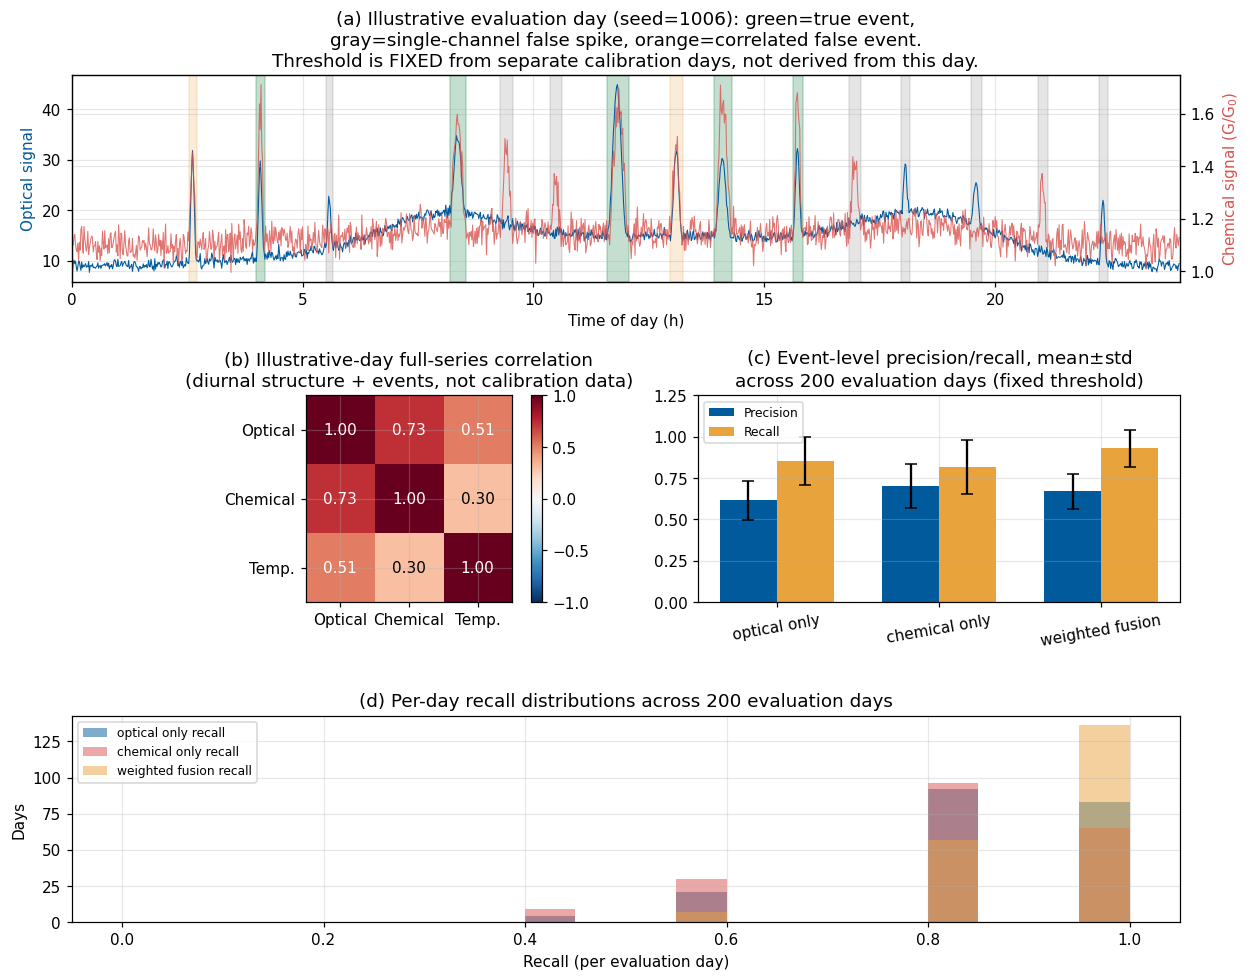

In [23]:
# ── Figure 11.4 ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 10))
gs = fig.add_gridspec(3, 2, hspace=0.55, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(day["hours"], day["optical"], color=ELS_BLUE, lw=0.7, label="Optical PM proxy")
ax1.set_ylabel("Optical signal", color=ELS_BLUE)
ax1b = ax1.twinx()
ax1b.plot(day["hours"], day["chem"], color=RED, lw=0.7, alpha=0.8, label="Chemical G/G0 (MOS model)")
ax1b.set_ylabel("Chemical signal (G/G$_0$)", color=RED)
color_map = {"true": GREEN, "false_optical": "gray", "false_chem": "gray", "false_correlated": ORANGE}
for s, dur, k, delay in day["event_log"]:
    end_h = (s + dur + max(delay, 0)) / 60
    ax1.axvspan(s/60, end_h, color=color_map[k], alpha=0.28 if k == "true" else 0.20)
ax1.set_xlabel("Time of day (h)"); ax1.set_xlim(0, 24)
ax1.set_title(f"(a) Illustrative evaluation day (seed={ILLUSTRATIVE_SEED}): green=true event,\ngray=single-channel false spike, orange=correlated false event.\nThreshold is FIXED from separate calibration days, not derived from this day.")

ax2 = fig.add_subplot(gs[1, 0])
labels = ["Optical", "Chemical", "Temp."]
im = ax2.imshow(day["corr_matrix"], cmap="RdBu_r", vmin=-1, vmax=1)
ax2.set_xticks(range(3)); ax2.set_xticklabels(labels)
ax2.set_yticks(range(3)); ax2.set_yticklabels(labels)
for i in range(3):
    for j in range(3):
        ax2.text(j, i, f"{day['corr_matrix'][i,j]:.2f}", ha="center", va="center",
                  color="white" if abs(day['corr_matrix'][i,j]) > 0.5 else "black")
ax2.set_title("(b) Illustrative-day full-series correlation\n(diurnal structure + events, not calibration data)")
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[1, 1])
names = detectors
p_means = [mc_summary[n][0] for n in names]; p_stds = [mc_summary[n][1] for n in names]
r_means = [mc_summary[n][2] for n in names]; r_stds = [mc_summary[n][3] for n in names]
x = np.arange(len(names)); width = 0.35
ax3.bar(x - width/2, p_means, width, yerr=p_stds, capsize=4, label="Precision", color=ELS_BLUE)
ax3.bar(x + width/2, r_means, width, yerr=r_stds, capsize=4, label="Recall", color=ORANGE)
ax3.set_xticks(x); ax3.set_xticklabels(names, rotation=10); ax3.set_ylim(0, 1.25)
ax3.set_title(f"(c) Event-level precision/recall, mean$\\pm$std\nacross {N_DAYS} evaluation days (fixed threshold)")
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[2, :])
for name, color in zip(detectors, [ELS_BLUE, RED, ORANGE]):
    ax4.hist(mc[name]["recall"], bins=np.linspace(0, 1, 21), alpha=0.5, label=f"{name} recall", color=color)
ax4.set_xlabel("Recall (per evaluation day)"); ax4.set_ylabel("Days")
ax4.set_title("(d) Per-day recall distributions across 200 evaluation days")
ax4.legend(fontsize=8)

plt.show()

### Analysis

With calibration and evaluation properly separated, fusion's advantage is concentrated in **recall** rather than precision: recall is about 0.93 and precision is about 0.67, both averaged over 200 evaluation days using a threshold fixed once during calibration. Fusion's recall is both higher and less variable than either single channel's, while its precision is not reliably better than chemical-only's, for a specific and identifiable reason: the correlated false events raise both channels together in exactly the way a genuine event does, and a score-level average has no basis on which to tell the two apart.

This remains an honestly-reported limitation, not a failure of the method. Distinguishing a correlated confound from a genuine event would need additional information a simple two-channel score-level average does not have: a third, differently-correlated channel; a known physical signature that differs between the two; or a slower-timescale contextual check.

### Key takeaway
> A threshold calibrated on the same data it is then evaluated against — even indirectly, even only to identify which minutes count as "quiet" — can leak information about that data's answer key into the detector's own decision boundary. The effect here was modest precisely *because* the underlying detection mechanism was sound; the fix was still necessary, because the size of a leakage effect is not something you can know in advance without removing the leakage and checking. Splitting calibration and evaluation into disjoint data, and never touching ground truth before a detection decision is final, is the same discipline that motivates a held-out test set in any predictive modelling task.

### Challenge tasks
1. Vary the number of calibration days from 10 to 100 and plot how much the fixed threshold (and the resulting evaluation precision/recall) fluctuates run to run. How many calibration days are enough for the threshold to stabilise?
2. Increase `n_false_correlated` and see how quickly fusion's precision advantage over chemical-only (if any) disappears as correlated confounds become more common.
3. Design a feature that WOULD let the detector distinguish a correlated false event from a true event (e.g., a different expected ratio between the two channels' peak amplitudes, or a different rise time), and test whether adding it recovers some of fusion's lost precision.
4. Increase `MAX_CHEM_DELAY` to 10-15 minutes and re-run the 200-day evaluation with the same fixed threshold. At what delay does fusion's recall advantage start to shrink?


---
## Practice Section Summary

| Exercise | Technique | Practical benefit |
|---|---|---|
| 11.1 | One-to-one peak matching, precision/recall/F1, mixture-robustness check | Reveals a spurious-peak failure mode AND a closed-world evaluation assumption |
| 11.2 | Power-law calibration bracketing the LOD, band-wise relative error | Honest, band-wise calibration accuracy instead of one RMSE dominated by the top of the range |
| 11.3 | Cluster (identity-level) bootstrap ROC/EER | A confidence interval that respects the real dependency structure of pairwise comparison data |
| 11.4 | Empirically-calibrated threshold, multi-day Monte Carlo, correlated false events | A precision/recall claim averaged over many trials, with an honestly-reported limitation |

Peak detection, power-law calibration, ROC/EER analysis, and score-level fusion are all standard, well-established signal-processing techniques -- but a technique is only as trustworthy as the evaluation built around it. A lenient scoring rule can hide a spurious-detection problem; an under-powered sample, or a bootstrap that resamples the wrong unit, can make a confidence interval look narrower than the data justify; a detection threshold can be presented as principled without actually following from what it claims to follow from; a single simulated run can stand in misleadingly for a distribution; and a threshold can be quietly calibrated on the same data it is then evaluated against. This is the same theme that runs through the multi-sensor fusion discussion of Chapter 10 (Section 10.2.5) and the data fusion and edge-computing material of Section 11.2.4: a fusion or estimation method is only as trustworthy as the evaluation built around it.
